# 01: How good are these sentiment models, really?

My first version of this project compared VADER with a RoBERTa transformer on 500 Amazon food reviews and
concluded that RoBERTa was "clearly" better, without calculating a single score. This notebook does it properly:
seven models, the same 10,000 held-out reviews, macro-F1 with confidence intervals, and a look at where each one
goes wrong.

The work happens in `uv run dap sentiment train` (code in `src/dap/sentiment/`), which writes
`reports/sentiment/results.json` and the figures. This notebook reads them. To run it yourself, run
`dap sentiment fetch` and `dap sentiment train` first.

In [1]:
import pandas as pd
from IPython.display import Image, display

from dap.common import paths
from dap.common.io import read_json
from dap.sentiment.evaluate import LENGTH_LABELS
from dap.sentiment.readme import ORDER, difference
from dap.sentiment.train import predictions_path

pd.set_option("display.precision", 3)
pd.set_option("display.max_colwidth", 220)
REPORTS = paths.reports_dir() / "sentiment"
r = read_json(REPORTS / "results.json")
models = r["models"]


def show(name):
    display(Image(filename=REPORTS / "figures" / name, width=760))

## The data, and why duplicates matter

Amazon shows a review on every variant of a product, so the same text appears again and again in this dataset.
If one copy ends up in training and another in testing, a model gets marked on reviews it has already seen. I
removed duplicates *before* splitting, then split by reviewer, so nobody's reviews are on both sides.

In [2]:
d = r["data"]
pd.Series(
    {
        "reviews in the file": d["reviews"],
        "same reviewer, same text (removed)": d["dropped_same_reviewer_same_text"],
        "same text, different reviewers, same label (one kept)": d[
            "dropped_cross_reviewer_same_label"
        ],
        "same text, different reviewers, different labels (all removed)": d[
            "dropped_cross_reviewer_conflicting_label"
        ],
        "reviews kept": d["after_dedupe"],
        "training reviews": d["train_reviews"],
        "validation reviews": d["validation_reviews"],
        "test reviews": d["test_reviews"],
        "evaluation sample (from test)": d["eval_sample"],
    }
).to_frame("count")

,count
reviews in the file,568454
"same reviewer, same text (removed)",175286
"same text, different reviewers, same label (one kept)",37
"same text, different reviewers, different labels (all removed)",16
reviews kept,393115
training reviews,274592
validation reviews,40235
test reviews,78288
evaluation sample (from test),10000


Almost a third of the file is repeats. My first version just took the first 500 rows of the file, without
removing any. The evaluation sample keeps the real mix of labels, which is very
lopsided:

In [3]:
pd.Series(d["eval_label_share"]).to_frame("share of evaluation sample")

,share of evaluation sample
negative,0.145
neutral,0.076
positive,0.779


With nearly four in five reviews positive, a model that always says "positive" gets high accuracy and learns
nothing. That's why I use **macro-F1**, the average of the F1 scores for the three classes, so the small neutral
class counts as much as the big positive one.

## The headline numbers

In [4]:
rows = []
for m in ORDER:
    x = models[m]
    f1 = x["macro_f1"]
    rows.append(
        {
            "model": x["label"],
            "macro-F1": f1["estimate"],
            "95% interval": f"{f1['ci_low']:.3f} to {f1['ci_high']:.3f}",
            "accuracy": x["accuracy"],
            "negative recall": x["per_class"]["negative"]["recall"],
            "neutral recall": x["per_class"]["neutral"]["recall"],
            "positive recall": x["per_class"]["positive"]["recall"],
        }
    )
pd.DataFrame(rows).set_index("model")

,macro-F1,95% interval,accuracy,negative recall,neutral recall,positive recall
model,,,,,,
"VADER, default thresholds",0.467,0.456 to 0.478,0.797,0.377,0.037,0.949
"VADER, thresholds tuned on validation",0.508,0.496 to 0.520,0.750,0.414,0.242,0.862
TF-IDF + logistic regression,0.694,0.681 to 0.706,0.851,0.777,0.524,0.896
"RoBERTa (Twitter sentiment, zero-shot)",0.593,0.582 to 0.605,0.815,0.748,0.200,0.887
"RoBERTa, decision rule tuned on validation",0.615,0.603 to 0.627,0.817,0.616,0.329,0.902
"RoBERTa, recalibrated on validation (logistic regression)",0.603,0.593 to 0.614,0.743,0.683,0.510,0.777
"DistilRoBERTa, fine-tuned on training reviews",0.679,0.666 to 0.691,0.838,0.791,0.503,0.880


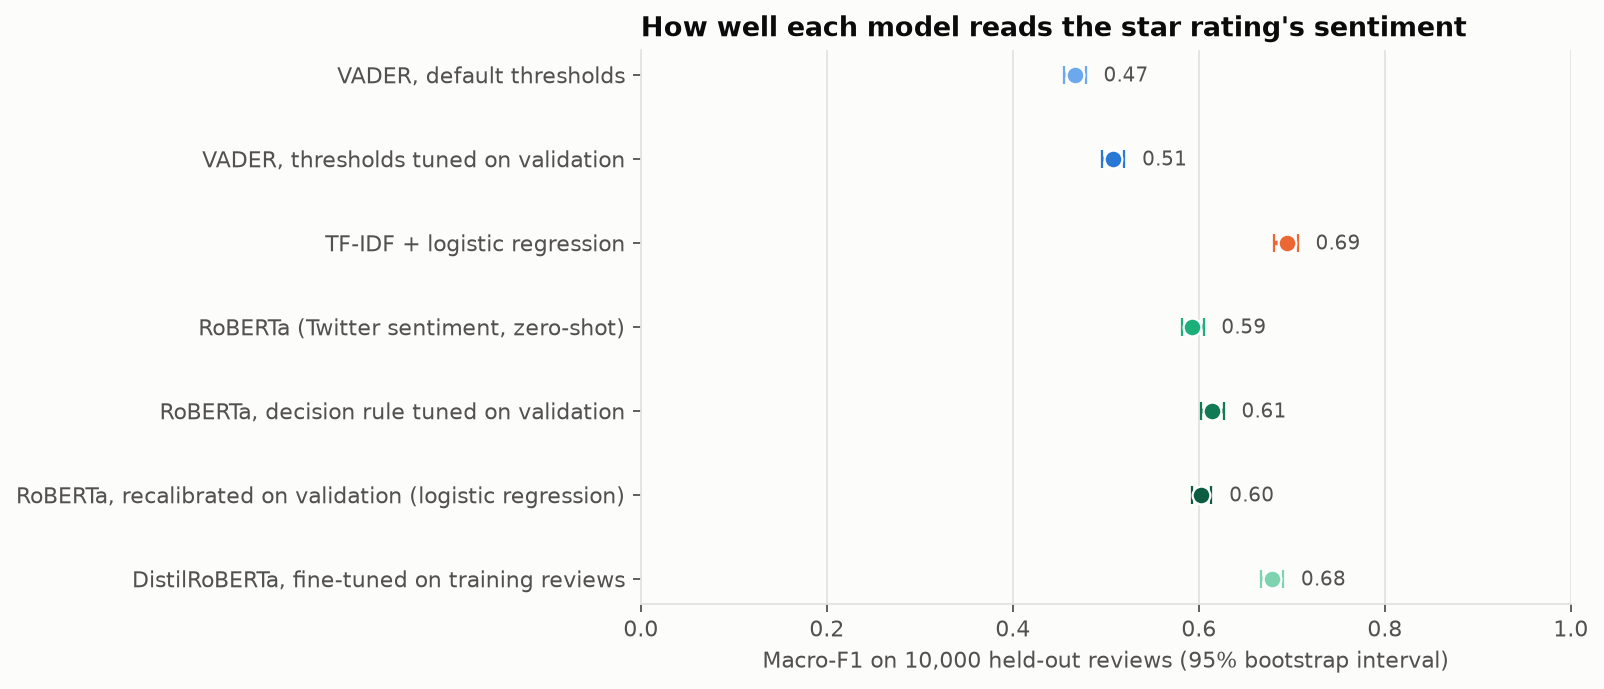

In [5]:
show("01_macro_f1.png")

In [6]:
pairs = [
    ("roberta", "vader_default"),
    ("roberta", "vader_tuned"),
    ("tfidf_logistic", "roberta"),
    ("vader_tuned", "vader_default"),
    ("roberta_tuned", "roberta"),
    ("tfidf_logistic", "roberta_tuned"),
    ("roberta_calibrated", "roberta"),
    ("roberta_calibrated", "roberta_tuned"),
    ("finetuned", "roberta"),
    ("finetuned", "tfidf_logistic"),
]
pd.DataFrame(
    {
        f"{models[a]['label']} minus {models[b]['label']}": difference(r["differences"], a, b)
        for a, b in pairs
    }
).T.rename(columns={"estimate": "difference in macro-F1"})

,difference in macro-F1,ci_low,ci_high
"RoBERTa (Twitter sentiment, zero-shot) minus VADER, default thresholds",0.126,1.115e-01,0.142
"RoBERTa (Twitter sentiment, zero-shot) minus VADER, thresholds tuned on validation",0.085,6.927e-02,0.102
"TF-IDF + logistic regression minus RoBERTa (Twitter sentiment, zero-shot)",0.101,8.460e-02,0.116
"VADER, thresholds tuned on validation minus VADER, default thresholds",0.041,2.927e-02,0.053
"RoBERTa, decision rule tuned on validation minus RoBERTa (Twitter sentiment, zero-shot)",0.021,1.097e-02,0.032
"TF-IDF + logistic regression minus RoBERTa, decision rule tuned on validation",0.080,6.416e-02,0.095
"RoBERTa, recalibrated on validation (logistic regression) minus RoBERTa (Twitter sentiment, zero-shot)",0.010,-2.944e-04,0.019
"RoBERTa, recalibrated on validation (logistic regression) minus RoBERTa, decision rule tuned on validation",-0.012,-2.103e-02,-0.002
"DistilRoBERTa, fine-tuned on training reviews minus RoBERTa (Twitter sentiment, zero-shot)",0.085,6.963e-02,0.100
"DistilRoBERTa, fine-tuned on training reviews minus TF-IDF + logistic regression",-0.016,-2.808e-02,-0.003


The intervals come from a **paired bootstrap**: I resample the 10,000 reviews 2,000 times and score every model on
the same resample each time. That gives an interval for the *difference* between two models, which is what my
original claim needed.

- **RoBERTa does beat VADER**, by a clear margin, with or without tuning VADER's thresholds. So my first
  conclusion was right in direction. I just hadn't shown it.
- **But a plain TF-IDF and logistic regression model beats RoBERTa,** and the whole interval for that difference is
  above zero. It's a much simpler model, but it was trained on food reviews, while RoBERTa was trained on tweets and
  never saw this data. Because the model and the training data both change at once, this doesn't tell me which one
  matters more.
- **Tuning VADER's thresholds helps a little,** mostly by letting it say "neutral" more often. Its accuracy actually
  drops, which is a good example of why accuracy is the wrong score for lopsided data.
- **Re-mapping RoBERTa's scores barely helps.** I gave RoBERTa the same chance as VADER in two ways, both fitted on
  5,000 validation reviews: an offset on the log probability of negative and neutral, picked by grid search, and a
  logistic regression on its three log probabilities. The offsets give a real but small gain (the interval is
  above zero), and the regression does slightly worse than the offsets. TF-IDF is still clearly ahead of both,
  so the gap isn't just RoBERTa drawing its lines in the wrong places. The next section shows why.

## Where the predictions go

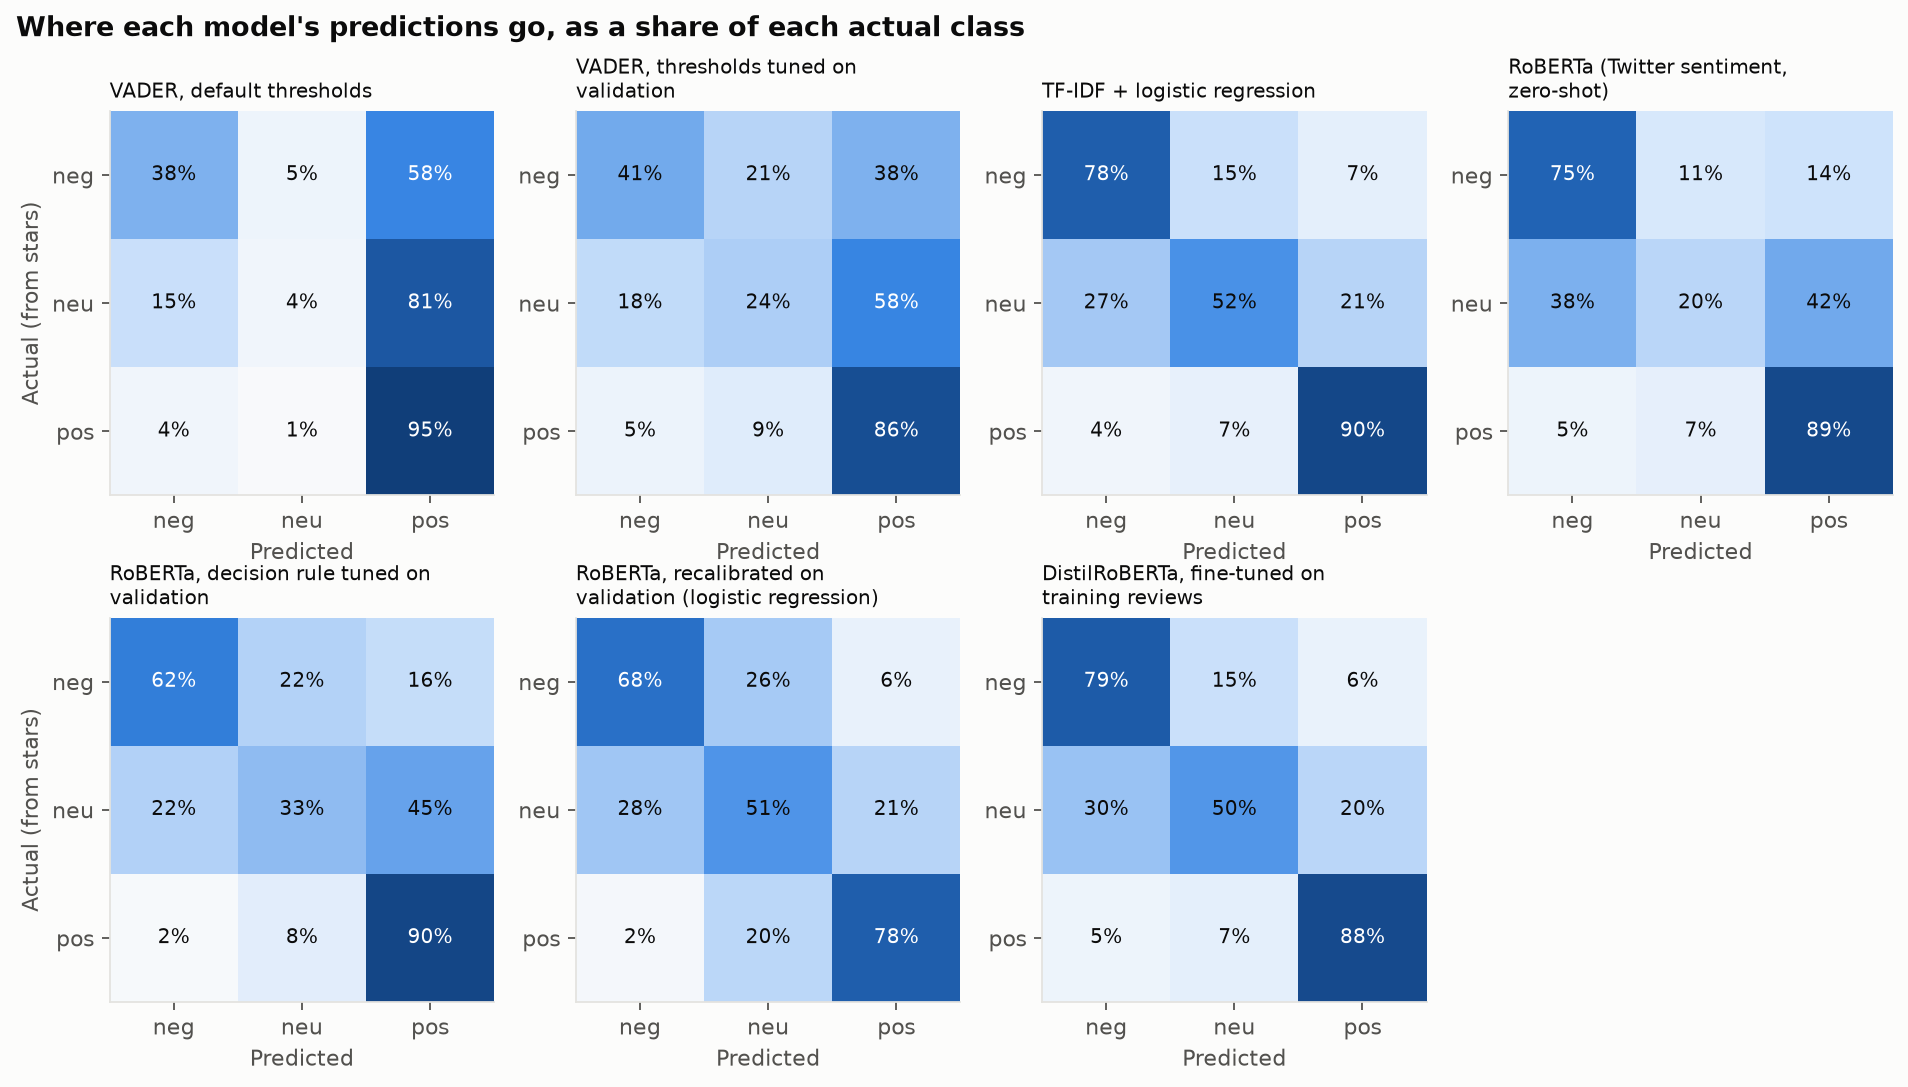

In [7]:
show("01_confusion.png")

Reading across each row (the actual label):

- **VADER with default thresholds calls most negative reviews positive** and almost never says neutral. It scores
  words, and food reviews are full of positive words even when the review isn't ("Paid a good chunk of cash for
  nothing" scores as fairly positive, because of "good").
- **Every model struggles with neutral,** but RoBERTa especially. That makes sense once you look at what 3-star
  reviews actually say (below): they're mostly mild complaints or mixed feelings, while the Twitter model's
  "neutral" means "no sentiment at all".
- **The tuned rule doesn't do what I expected.** I thought it would push RoBERTa towards neutral. Instead it
  makes RoBERTa slower to say negative: zero-shot, it calls a lot of three-star reviews negative, and with the
  tuned rule those move to neutral. Some real negatives move too, so negative recall drops.
- **TF-IDF gets the most neutrals right** because it learnt what 3-star reviews look like (words like "ok",
  "but" and "decent") and because it was trained with balanced class weights.

## Does review length matter?

In [8]:
rows = {}
for m in ("roberta", "roberta_tuned", "roberta_calibrated", "finetuned"):
    for c, s in models[m]["per_class"].items():
        rows[(models[m]["label"], c)] = {k: s[k] for k in ("precision", "recall", "f1")}
pd.DataFrame(rows).T.unstack().swaplevel(axis=1).sort_index(axis=1, level=0)

negative            \
                                                                f1 precision   
DistilRoBERTa, fine-tuned on training reviews                0.720     0.660   
RoBERTa (Twitter sentiment, zero-shot)                       0.681     0.625   
RoBERTa, decision rule tuned on validation                   0.675     0.746   
RoBERTa, recalibrated on validation (logistic regression)    0.696     0.709   

                                                                 neutral  \
                                                          recall      f1   
DistilRoBERTa, fine-tuned on training reviews              0.791   0.395   
RoBERTa (Twitter sentiment, zero-shot)                     0.748   0.191   
RoBERTa, decision rule tuned on validation                 0.616   0.256   
RoBERTa, recalibrated on validation (logistic regression)  0.683   0.253   

                                                                            \
                                                          precision recall   
DistilRoBERTa, fine-tuned on training reviews                 0.325  0.503   
RoBERTa (Twitter sentiment, zero-shot)                        0.182  0.200   
RoBERTa, decision rule tuned on validation                    0.209  0.329   
RoBERTa, recalibrated on validation (logistic regression)     0.168  0.510   

                                                          positive            \
                                                                f1 precision   
DistilRoBERTa, fine-tuned on training reviews                0.921     0.967   
RoBERTa (Twitter sentiment, zero-shot)                       0.908     0.930   
RoBERTa, decision rule tuned on validation                   0.913     0.924   
RoBERTa, recalibrated on validation (logistic regression)    0.860     0.961   

                                                                  
                                                          recall  
DistilRoBERTa, fine-tuned on training reviews              0.880  
RoBERTa (Twitter sentiment, zero-shot)                     0.887  
RoBERTa, decision rule tuned on validation                 0.902  
RoBERTa, recalibrated on validation (logistic regression)  0.777

Per class, the RoBERTa variants tell one story. Each re-mapping trades one error for another. The offsets cut
negative calls, so negative precision goes up and negative recall comes down. The regression finds more neutrals,
but mostly by calling positive reviews neutral. What none of them change is **neutral precision**: only about one in
five of RoBERTa's neutral calls is right, however its scores are re-mapped, so neutral F1 stays around a quarter.
The fine-tuned model, which learnt from these reviews, gets that to about a third.

So I read the tuned rule as a diagnosis rather than an improvement. Zero-shot RoBERTa puts three-star reviews into
negative because its "neutral" means "no sentiment" (that's what it means on Twitter), while a three-star food
review is usually a mild complaint. A better boundary can't fix that, because the scores themselves don't separate
those reviews. The settings behind both re-mappings are in `results.json`:

In [9]:
s = r["settings"]
print("offsets:", s["roberta_tuned_log_offsets"], "grid:", s["roberta_offset_grid"])
print("best pair inside the grid (not on its edge):", s["roberta_offsets_inside_grid"])
weights = s["roberta_calibrated_class_weight"]
print("regression class weights:", weights, s["roberta_calibrated_search"])

offsets: {'negative': -1.0, 'neutral': -0.2, 'positive': 0.0} grid: {'high': 3.0, 'low': -3.0, 'step': 0.1}
best pair inside the grid (not on its edge): True
regression class weights: balanced {'None': 0.5425, 'balanced': 0.6055}


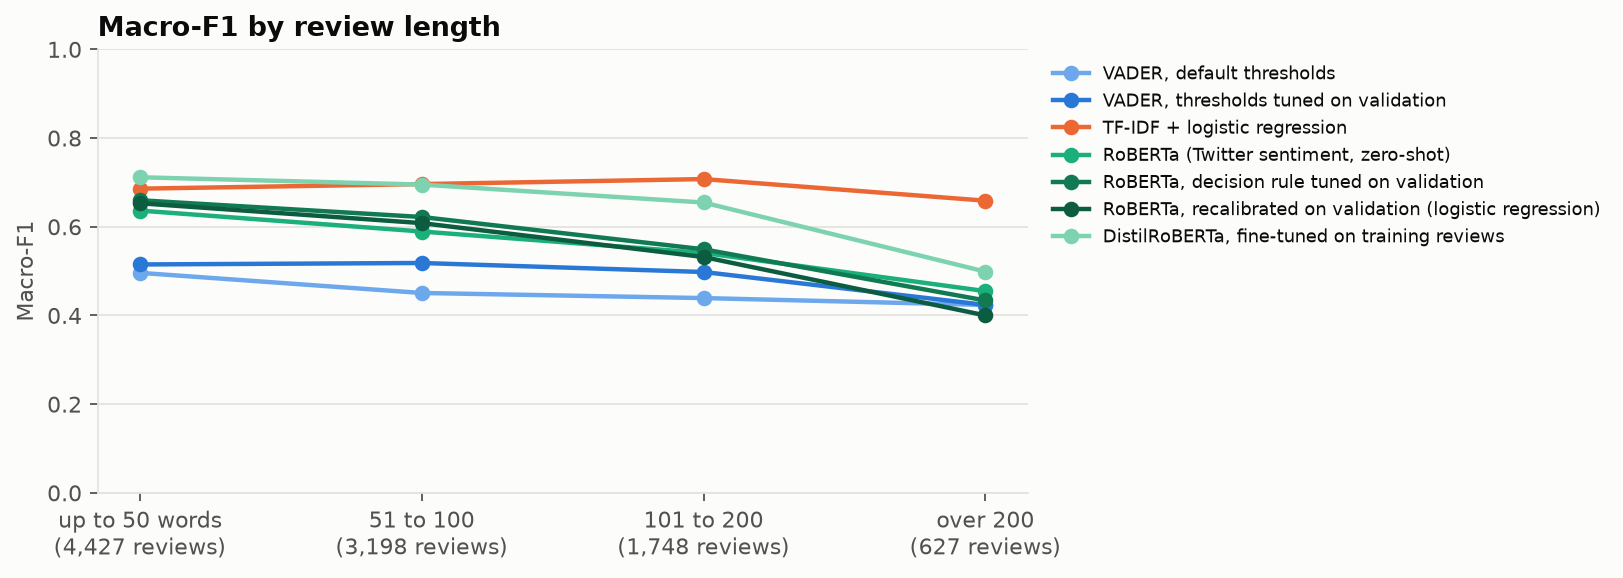

,n,vader_default,vader_tuned,tfidf_logistic,roberta,roberta_tuned,roberta_calibrated,finetuned
up to 50 words,4427.0,0.496,0.515,0.686,0.636,0.660,0.653,0.712
51 to 100,3198.0,0.451,0.518,0.696,0.589,0.622,0.608,0.695
101 to 200,1748.0,0.439,0.498,0.708,0.541,0.549,0.532,0.655
over 200,627.0,0.424,0.424,0.659,0.455,0.434,0.400,0.499


In [10]:
show("01_length.png")
by = r["slices"]
pd.DataFrame(by["length"]).T.loc[LENGTH_LABELS, ["n", *ORDER]]

RoBERTa gets steadily worse as reviews get longer, while TF-IDF stays roughly flat. Only a small number of
reviews are longer than RoBERTa's 512-token limit, so truncation isn't the main reason. My guess is that longer
reviews tell more of a story (what they expected, what happened, what was good and bad), which is unlike the
tweets RoBERTa was trained on. I can't prove that from these numbers.

In [11]:
pd.DataFrame(
    {
        f"{g}: {k}": v
        for g in ("truncated_by_roberta", "contrast_word", "mentions_stars")
        for k, v in by[g].items()
    }
).T[["n", *ORDER]]

,n,vader_default,vader_tuned,tfidf_logistic,roberta,roberta_tuned,roberta_calibrated,finetuned
truncated_by_roberta: fits in 512 tokens,9919.0,0.467,0.508,0.694,0.594,0.616,0.604,0.681
truncated_by_roberta: truncated,81.0,0.398,0.392,0.655,0.460,0.405,0.370,0.439
contrast_word: has a contrast word,4910.0,0.440,0.503,0.673,0.558,0.580,0.567,0.647
contrast_word: none,5090.0,0.501,0.509,0.690,0.629,0.642,0.624,0.694
mentions_stars: mentions stars,409.0,0.409,0.443,0.689,0.523,0.541,0.528,0.602
mentions_stars: no mention,9591.0,0.470,0.511,0.690,0.596,0.616,0.605,0.680


Two more checks:

- **Contrast words** ("but", "however", "although"...) are a rough stand-in for reviews that say two things. It's
  only a proxy, and about half of all reviews contain one, so I don't read much into it. Every model does a bit
  worse on them, RoBERTa the most.
- **Reviews that mention stars.** TF-IDF's most useful words include "two stars" and "three stars", because some
  people write their rating in the text. I worried that this was doing a lot of the work, but only a small share of
  reviews mention stars, and TF-IDF scores about the same on the reviews that don't. So it isn't the explanation.

## Does fine-tuning close the gap?

Tuning RoBERTa's rule didn't close the gap, so the obvious question is whether TF-IDF wins because it learnt
from food reviews, or because it's a better fit for this job. So I fine-tuned a transformer on the training reviewers too. My laptop has no GPU,
so I kept it small: DistilRoBERTa (a smaller RoBERTa), 20,000 training reviews with the same label mix as the full
split, each review cut to its first 128 tokens, and one pass over the data, with the checkpoint picked on 2,000
validation reviews. That took about 45 minutes. TF-IDF, for comparison, learnt from all of the training reviews,
every word of them.

Fine-tuning closes most of the gap to TF-IDF, but not all of it. The split by length shows where the rest goes:

In [12]:
ft = r["settings"]["finetuned"]
print(
    f"{ft['model']}: {ft['training_reviews']:,} training reviews, "
    f"first {ft['max_length']} tokens, validation macro-F1 {ft['validation_macro_f1']:.3f}"
)
pd.DataFrame(by["cut_for_finetuned"]).T[["n", *ORDER]]

distilbert/distilroberta-base: 20,000 training reviews, first 128 tokens, validation macro-F1 0.669


,n,vader_default,vader_tuned,tfidf_logistic,roberta,roberta_tuned,roberta_calibrated,finetuned
cut,2296.0,0.432,0.476,0.701,0.519,0.524,0.495,0.608
fits in 128 tokens,7704.0,0.478,0.516,0.689,0.615,0.640,0.633,0.704


On reviews that fit in 128 tokens, the fine-tuned model is at least as good as TF-IDF. On the longer ones, where it
only sees the start, it falls well behind, and the length chart above shows the same thing. So most of RoBERTa's
gap was the training data (tweets instead of reviews), and what's left looks like what I cut to make it run on a
CPU: less training data and shorter reviews. I can't separate those two from this one run.

## Some of the mistakes

A few reviews I picked out while reading through the errors, cut to 200 characters. These are real reviews,
shown by id only.

In [13]:
preds = pd.read_pickle(predictions_path()).set_index("review_id")
cols = ["score", "pred_vader_default", "pred_tfidf_logistic", "pred_roberta"]


def examples(ids):
    out = preds.loc[ids, ["text", *cols]].copy()
    long = out.text.str.len() > 200
    out["text"] = out.text.where(~long, out.text.str.slice(0, 197) + "...")
    return out.rename(columns=lambda c: c.replace("pred_", ""))


print("One star, but the words are about how good the product is:")
display(examples([97118, 99584, 102524]))

One star, but the words are about how good the product is:


,text,score,vader_default,tfidf_logistic,roberta
review_id,,,,,
97118,"This stuff is great. I ordered a three pack last week for $13.39 here at amazon. I went to re-order today and's it's $18.74. What's up with that? This stuff is good, but at the new price ...I will ...",1,positive,positive,positive
99584,"I was excited to find this and read the great reviews. I ordered it at $15+ from Amazon, and it does work and taste great in our large school popcorn maker. HOWEVER, it's offered for $3.48 at our l...",1,positive,negative,positive
102524,"I love Torani Syrup. The flavor is rich and comes thru with every, in my case, cup of coffee. Coffee just is the great without Torani.",1,positive,positive,positive


The first two are about the price, not the food: the stars describe the purchase, but most of the words describe
the product. The third ("I love Torani Syrup...") reads like a five-star review with a one-star rating, which is
probably just a mistake by the reviewer. No model can get that right, and there will be more like it. So none of
these models could reach a perfect score, even in principle.

In [14]:
print("VADER's default thresholds call these negative reviews positive:")
display(examples([229, 7068]))
print("Three-star reviews:")
display(examples([1811, 24970, 1792]))

VADER's default thresholds call these negative reviews positive:


,text,score,vader_default,tfidf_logistic,roberta
review_id,,,,,
229,This candy is not as described. The middle is almost hard it is not a silky or smooth filling as described. Looks and tastes like it's way past it's expiration date. Would never reccommend this. Pa...,1,positive,negative,negative
7068,The lids are impossible to secure. This purchase was a complete waste of money. Product cannot be used as lids are unable to be secured.,1,positive,negative,negative


Three-star reviews:


,text,score,vader_default,tfidf_logistic,roberta
review_id,,,,,
1811,"Not anything to rave about. They were okay. I think if I truly had a craving for chips I would just buy and eat ""regular"" ones. Won't buy again.",3,positive,negative,neutral
24970,Good coffee just not my style. I gave it a try with the reviews but it's not for me. I would give it 5 stars for the aroma!!,3,positive,neutral,negative
1792,"I am interested in these but was wondering if someone that has them could post some nutrition info on them? Mainly, fat, fiber, sugars, and then any vitamins? Thanks so much!!",3,positive,neutral,positive


- VADER adds up word scores. In the first review, "like" (in "tastes like it's way past its expiration date") and
  "good" (in "a good chunk of cash for nothing") are its only positive words, and the misspelt "reccommend" isn't
  in its dictionary at all. In the second, "secure" and "secured" are positive words, even though the complaint is
  that the lids *can't* be secured.
- The 3-star reviews show the label problem. "Won't buy again" is closer to negative than neutral, the coffee one
  is mixed, and the last one is a question, not a review at all. The star rating is a noisy label for sentiment,
  especially in the middle.

## What I'd say now

My original claim, "RoBERTa clearly outperforms VADER", holds up once it's measured. But the more useful finding
is that a simple model trained on these reviews beats a big model trained on tweets and used as is. Fine-tuning a
small transformer on the training reviews closes most of that gap, so it was mostly about the training data, not
the model.

## Limitations

- **The labels come from star ratings,** which mix sentiment with things like price, delivery and the occasional
  mistake. A model is marked wrong for disagreeing with the stars, even when the text supports it.
- **RoBERTa is used zero-shot,** with no training on food reviews. That's a fair test of the model I used before,
  and the fine-tuned model is the test of transformers trained on this data. The tuned rule and the recalibration only change how its scores become a
  class, not what it has learnt, and both are fitted on 5,000 validation reviews rather than all of them,
  because RoBERTa is slow on a laptop CPU.
- **The fine-tuned model saw less than TF-IDF did:** 20,000 reviews cut to 128 tokens, against all of the
  training reviews in full. With one run I can't say whether more data or longer inputs would matter more.
- **One dataset, one domain.** Amazon food reviews from 1999 to 2012.